<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB11 · Proyecto: el palo de escoba

**Parte 1 · Primeros pasos con el ordenador — Lección 7 (proyecto final)**

> Llevas seis lecciones construyendo herramientas: `print` (NB05), variables (NB06), bucles (NB07),
> decisiones (NB08), listas (NB09) y funciones (NB10). Hoy no vas a aprender casi nada nuevo. Hoy vas a
> **usarlo todo junto** para construir algo de verdad.

Vamos a construir, **desde cero y con tus propias manos**, un mundo completo de aprendizaje por refuerzo:
un robot de juguete que tiene que **mantener en equilibrio un palo de escoba**. Sí, el mismo palo de escoba
sobre la palma de la mano con el que empezó el curso, en el NB00.

Tendrá **todo** lo que vimos en la Parte 0, ahora en código:

| Pieza (Parte 0) | En este proyecto |
|---|---|
| El cuerpo y el mundo (NB01, NB02) | Una física de juguete, a pasitos, con gravedad, un motor y viento |
| La mente: observación → acción (NB03) | Funciones que reciben la inclinación y deciden un empuje |
| La recompensa (NB04) | Un número por paso: más puntos cuanto más derecho esté el palo |
| Episodios que terminan (NB03, NB08) | Si el palo se inclina más de 30 grados, se acabó |
| Comparar políticas (NB04, NB10) | Retorno medio en los mismos mundos |
| Aprender probando (NB00) | El ordenador busca **solo** una buena política |

Al final habrás hecho tu **primer aprendizaje por refuerzo**. Pequeñito, pero de verdad. Y en la práctica
final construirás este mismo robot **en MuJoCo**, con física de verdad, y le enfrentarás tus políticas.

Es una lección larga. Tómatela en varios ratos si quieres; cada apartado deja algo terminado.


## 1 · El problema: un palo que se cae

Imagina un palo de escoba de pie sobre un **carrito** (o sobre tu mano). El palo tiende a caerse: en cuanto
se inclina un poco, la gravedad lo inclina más, y cada vez más deprisa. Nuestro robot de juguete tiene **un
solo motor** que puede **empujar** la base hacia un lado o hacia el otro, para "ponerse debajo" del palo y
enderezarlo. Como tu mano con la escoba.

```
         inclinación
          (grados)
            ╲  │
             ╲ │            el palo se inclina hacia un lado;
              ╲│            el motor empuja la base para corregir
          ┌────●────┐
          │ carrito │  ◄── empuje ──►
          └─o─────o─┘
   ═══════════════════════════  suelo
```

Este problema es tan clásico que tiene nombre propio entre los investigadores: se parece mucho al
**"carro con péndulo"** (*CartPole*), uno de los primeros problemas con los que se probó el aprendizaje por
refuerzo, hace más de 40 años, y con el que todavía hoy empieza casi todo el mundo.

Antes de programar nada, hagamos lo que haría un profesional: escribir la **ficha del entorno**. Es la
descripción de qué observa el agente, qué puede hacer, qué puntos recibe y cuándo termina:

| | Nuestro palo de escoba |
|---|---|
| **Observación** | 2 números: la **inclinación** (grados; positiva hacia un lado, negativa hacia el otro) y la **velocidad de giro** (grados por segundo) |
| **Acción** | 1 número: el **empuje** del motor, entre −40 y +40 |
| **Recompensa por paso** | 1 − (inclinación / 30)²: **1 punto** si está perfectamente derecho, **menos** cuanto más inclinado |
| **Terminado** | Si la inclinación pasa de **30 grados** (hacia cualquier lado): el palo se ha caído |
| **Truncado** | A los **500 pasos** (10 segundos; cada paso son 0,02 s) |
| **Mejor retorno posible** | Casi **500** (500 pasos × casi 1 punto) |

Compárala con la del humanoide: allí la observación tenía 45 números y la acción 17. Aquí, 2 y 1. Es el
mismo tipo de problema, en miniatura.

(¿Ves la recompensa? Es **densa** —da puntos en cada paso, como el "frío, caliente" del NB04— y usa el
**cuadrado** para castigar mucho más las inclinaciones grandes que las pequeñas.)


## 2 · La física de juguete

Necesitamos una "cadena de oro" (NB02) para el palo. Usaremos una versión **simplificada** a propósito: no es
la física exacta de una escoba (esa necesita matemáticas que aún no hemos visto), pero **se comporta como
una**, que es lo que importa para aprender. En cada pasito:

```
   aceleración de giro = 10 × inclinación  +  empuje del motor  +  viento
                         ──────────────────   ───────────────      ──────
                         la gravedad: cuanto   lo que decide la    un empujoncito al
                         MÁS inclinado, MÁS    política (limitado  azar en cada paso
                         rápido se cae         a ±40)              (entre −30 y +30)

   velocidad de giro = velocidad de giro + aceleración × 0,02      (fuerza → velocidad)
   inclinación       = inclinación + velocidad de giro × 0,02      (velocidad → posición)
```

Las dos últimas líneas son **exactamente** las de la pelota del NB06-NB07. La primera tiene tres
ingredientes:

- **La gravedad, `10 × inclinación`.** Fíjate: si el palo está derecho (inclinación 0), la gravedad no lo
  tumba hacia ningún lado. Pero si está inclinado 2 grados, lo empuja a caer más; si está inclinado 10, lo
  empuja **cinco veces más**. Por eso un palo inclinado se cae cada vez más deprisa: es la **inestabilidad**
  del NB00, metida en una fórmula.
- **El empuje del motor.** Lo decide la política. Está **limitado** a ±40, porque ningún motor es un
  superhéroe (NB01).
- **El viento.** Un número **al azar** en cada paso, entre −30 y +30. Representa todo lo que no controlamos
  (una corriente de aire, una vibración, el ruido de los sensores del NB01). Sin él, el problema sería
  demasiado fácil y poco realista.

Para el viento necesitamos algo que aún no sabemos hacer: **números al azar**. Es la primera (y casi la
única) idea nueva de hoy.


## 3 · Una idea nueva: números al azar

Python trae muchísimas herramientas **guardadas en cajas de herramientas** separadas, que no se cargan si no
las pides (así el ordenador no se llena de cosas que no usas). A esas cajas se les llama **módulos**. Hay un
módulo para el azar, que se llama **`random`** ("aleatorio"), y para usarlo hay que **importarlo**, es decir,
sacarlo del armario. Se hace una vez, normalmente al principio:


In [1]:
import random

No sale nada: solo hemos sacado la caja de herramientas. Ahora podemos usar lo que hay dentro, escribiendo
el nombre del módulo, **un punto**, y el nombre de la herramienta (como los métodos del NB09). La que
necesitamos es **`random.uniform(a, b)`**, que devuelve un número decimal **al azar entre `a` y `b`**:


In [2]:
print(random.uniform(-30, 30))
print(random.uniform(-30, 30))
print(random.uniform(-30, 30))

6.198908374245242
0.9394722250454492
-21.088162689703417


Tres números al azar entre −30 y +30, cada uno distinto. (Si ejecutas tú la celda, te saldrán **otros**
números: ¡son al azar!) Ese es nuestro viento.


### Repetir el mismo azar: la semilla

Pero tener azar trae un problema. Si queremos **comparar** dos políticas, ¿cómo sabemos que una ganó porque
es mejor y no porque **tuvo suerte** con el viento? En la vida real no se puede repetir exactamente el mismo
viento. Pero recuerda una de las ventajas del simulador (NB02): **se puede repetir exactamente el mismo
intento**.

Los números "al azar" de un ordenador en realidad salen de una receta matemática muy enrevesada que parte de
un número inicial, llamado **semilla**. Si fijas la semilla con **`random.seed(...)`**, la receta produce
**siempre la misma secuencia** de números "al azar". Mira: fijamos la semilla 7 y pedimos dos números; luego
**volvemos a fijar** la semilla 7 y pedimos otros dos:


In [3]:
random.seed(7)
print(random.uniform(-1, 1), random.uniform(-1, 1))

random.seed(7)
print(random.uniform(-1, 1), random.uniform(-1, 1))

-0.35233447033367526 -0.6983016521509962
-0.35233447033367526 -0.6983016521509962


¡Los **mismos** dos números las dos veces! Con la misma semilla, el mismo azar.

Esto nos da un superpoder para comparar políticas con justicia: a cada episodio le daremos una **semilla**, y
así **todas las políticas se enfrentarán exactamente al mismo viento**. Como en una competición de esquí en la
que todos bajan **la misma pista**: si uno gana, no es porque le tocara mejor nieve.


## 4 · Construyendo el mundo

Ya tenemos todas las piezas. Vamos a construir el entorno con **funciones** (NB10), pieza a pieza.

Primero, los números fijos del mundo. Por costumbre, los programadores escriben en **MAYÚSCULAS** los nombres
de las cajas que **no deben cambiar** durante el programa (se llaman **constantes**). Python no lo obliga; es
un aviso para quien lee: "esto es una regla del mundo, no lo toques":


In [4]:
PASO_TIEMPO = 0.02       # cada paso dura 0,02 segundos (50 decisiones por segundo)
EMPUJE_MAXIMO = 40       # la fuerza máxima del motor
VIENTO_MAXIMO = 30       # el viento sopla, al azar, entre -30 y +30
CAIDA = 30               # si se inclina más de 30 grados, se ha caído
PASOS_MAXIMOS = 500      # 500 pasos = 10 segundos

Segundo, cómo **empieza** cada episodio: el palo arranca **un poquito inclinado** (2 grados) y quieto. Si
empezara perfectamente derecho y sin viento, nunca se caería: no sería un reto.


In [5]:
def reiniciar():
    inclinacion = 2.0
    velocidad = 0.0
    return inclinacion, velocidad

## 5 · El corazón: la función de paso

Ahora, la pieza más importante: la **función de paso** (NB10), la que recibe el estado actual y la acción, y
devuelve lo que pasa un pasito después. Es nuestro "MuJoCo" de bolsillo. Devuelve **cuatro** cosas: la nueva
inclinación, la nueva velocidad, la recompensa del paso y si el episodio ha terminado.

Léela despacio, con sus comentarios. Cada línea es algo que ya conoces:


In [6]:
def paso(inclinacion, velocidad, empuje):
    # 1. El motor no es un superhéroe: limitamos el empuje a +-40 (NB01, NB08)
    if empuje > EMPUJE_MAXIMO:
        empuje = EMPUJE_MAXIMO
    if empuje < -EMPUJE_MAXIMO:
        empuje = -EMPUJE_MAXIMO

    # 2. El viento: un empujoncito al azar (lo nuevo de hoy)
    viento = random.uniform(-VIENTO_MAXIMO, VIENTO_MAXIMO)

    # 3. La física: la cadena de oro (NB02, NB06)
    aceleracion = 10 * inclinacion + empuje + viento
    velocidad = velocidad + aceleracion * PASO_TIEMPO
    inclinacion = inclinacion + velocidad * PASO_TIEMPO

    # 4. ¿Se ha caído? (NB08: una comparación ya es True o False)
    terminado = inclinacion > CAIDA or inclinacion < -CAIDA

    # 5. La recompensa (NB04): 1 si está derecho, menos cuanto más inclinado, 0 si ha caído
    if terminado:
        recompensa = 0
    else:
        recompensa = 1 - (inclinacion / CAIDA) ** 2

    return inclinacion, velocidad, recompensa, terminado

Probémosla con **un solo paso**: el palo inclinado 2 grados, quieto, y el motor **sin empujar** (empuje 0).
Fijamos una semilla para que el viento sea siempre el mismo:


In [7]:
random.seed(0)
inclinacion, velocidad, recompensa, terminado = paso(2.0, 0.0, 0)
print("inclinación:", round(inclinacion, 3), "| velocidad:", round(velocidad, 3))
print("recompensa:", round(recompensa, 4), "| ¿terminado?:", terminado)

inclinación: 2.016 | velocidad: 0.813
recompensa: 0.9955 | ¿terminado?: False


Tras un pasito, el palo se ha inclinado un poquito más (la gravedad y el viento lo han empujado), ha empezado
a girar, y la recompensa es casi 1 (sigue casi derecho). No ha terminado. **El mundo funciona.**


## 6 · Un episodio completo

Ahora, una función que juega **un episodio entero** con la política que le pasemos (como `simular_una_hora`
del NB10). Es el bucle agente-entorno del NB03, con todas sus piezas: reiniciar, y en cada paso, la política
decide, el mundo responde, se acumula la recompensa, y si el palo cae, `break` (NB08). Devuelve el **retorno**
(NB04) y cuántos pasos aguantó:


In [8]:
def episodio(politica, semilla):
    random.seed(semilla)                        # el mismo viento para todas las políticas
    inclinacion, velocidad = reiniciar()
    retorno = 0
    pasos_aguantados = 0

    for n in range(PASOS_MAXIMOS):
        empuje = politica(inclinacion, velocidad)                      # EL AGENTE
        inclinacion, velocidad, recompensa, terminado = paso(inclinacion, velocidad, empuje)  # EL ENTORNO
        retorno = retorno + recompensa
        pasos_aguantados = pasos_aguantados + 1
        if terminado:
            break

    return retorno, pasos_aguantados

Y otra función que juega **cinco episodios** (con las semillas 0, 1, 2, 3 y 4, siempre las mismas) y devuelve
el **retorno medio** (NB09). Una sola partida puede ser cuestión de suerte; la media de cinco es mucho más fiable
(recuerda la costumbre del NB04: **medir bien**):


In [9]:
def evaluar(politica):
    retornos = []
    for semilla in range(5):
        retorno, pasos_aguantados = episodio(politica, semilla)
        retornos.append(retorno)
    return sum(retornos) / len(retornos)

El mundo está terminado. Ahora, a probar políticas. Una política, recuerda (NB10), es una función que recibe la
observación (inclinación y velocidad) y devuelve una acción (el empuje).


## 7 · Política 1: no hacer nada

La más sencilla de todas: el motor nunca empuja. Es el "muñeco de trapo" del NB04. (Fíjate en que recibe la
observación, pero no la usa: decide lo mismo pase lo que pase.)


In [10]:
def politica_nada(inclinacion, velocidad):
    return 0

retorno, pasos_aguantados = episodio(politica_nada, 0)
print("Un episodio: retorno", round(retorno, 1), "| aguantó", pasos_aguantados, "pasos")
print("Media de 5 episodios:", round(evaluar(politica_nada), 1))

Un episodio: retorno 41.6 | aguantó 50 pasos
Media de 5 episodios: 44.8


El palo aguanta unos **50 pasos** (1 segundo) y luego se cae. Retorno medio: unos **45 puntos** de 500
posibles. La gravedad (con ayuda del viento) gana siempre.


## 8 · Política 2: moverse al azar

Como el humanoide del GIF del NB00: el motor empuja al azar, a lo loco, entre −40 y +40, sin mirar nada:

In [11]:
def politica_azar(inclinacion, velocidad):
    return random.uniform(-EMPUJE_MAXIMO, EMPUJE_MAXIMO)

print("Media de 5 episodios:", round(evaluar(politica_azar), 1))

Media de 5 episodios: 43.2


Unos **43 puntos**: ¡**incluso un poco peor que no hacer nada**! Exactamente lo que medimos con el humanoide en el
NB04 (el robot al azar sacaba 98 puntos y el muñeco de trapo, 198). Moverse sin saber no sirve: empujar al azar
es como añadir **más viento**.


## 9 · Política 3: escrita a mano (primera versión)

Ahora usemos la cabeza, como un ingeniero de **control clásico** (NB03). Recuerda la regla de la escoba:
"**si se inclina hacia un lado, empuja hacia ese lado** para ponerte debajo". En números: empujar **en contra**
de la inclinación (con el signo cambiado, como el rebote del NB08), y con más fuerza cuanto más inclinado
esté. Por ejemplo, 30 veces la inclinación:


In [12]:
def politica_solo_inclinacion(inclinacion, velocidad):
    return -30 * inclinacion

print("Media de 5 episodios:", round(evaluar(politica_solo_inclinacion), 1))

Media de 5 episodios: 296.0


**296 puntos de media**: ¡muchísimo mejor! Pero... no son 500. Algo falla a veces. Veamos episodio a episodio,
con un bucle sobre las cinco semillas:


In [13]:
for semilla in range(5):
    retorno, pasos_aguantados = episodio(politica_solo_inclinacion, semilla)
    print("semilla", semilla, "| retorno", round(retorno, 1), "| aguantó", pasos_aguantados, "pasos")

semilla 0 | retorno 499.7 | aguantó 500 pasos
semilla 1 | retorno 168.5 | aguantó 181 pasos
semilla 2 | retorno 144.5 | aguantó 157 pasos
semilla 3 | retorno 198.8 | aguantó 211 pasos
semilla 4 | retorno 468.3 | aguantó 481 pasos


En **dos** episodios aguanta (casi) los 500 pasos, pero en los otros **tres** el palo acaba cayéndose, a veces a
mitad del episodio. Para entender por qué, hagamos lo de los profesionales (NB09): **grabar** la trayectoria y
mirarla. Esta función es como `episodio`, pero en vez del retorno devuelve la **lista de inclinaciones**:


In [14]:
def grabar(politica, semilla):
    random.seed(semilla)
    inclinacion, velocidad = reiniciar()
    inclinaciones = []
    for n in range(PASOS_MAXIMOS):
        empuje = politica(inclinacion, velocidad)
        inclinacion, velocidad, recompensa, terminado = paso(inclinacion, velocidad, empuje)
        inclinaciones.append(inclinacion)
        if terminado:
            break
    return inclinaciones

Grabamos el episodio de la semilla 1 (uno de los que fallan) y miramos la inclinación **cada 20 pasos**. Para
eso usamos `range` con un **tercer número**, el **salto** (lo viste en el reto E8 del NB07): `range(0, 181, 20)`
da 0, 20, 40... hasta 180:


In [15]:
trayectoria = grabar(politica_solo_inclinacion, 1)
print("Pasos grabados:", len(trayectoria))
for i in range(0, len(trayectoria), 20):
    print("paso", i, "| inclinación", round(trayectoria[i], 1))

Pasos grabados: 181
paso 0 | inclinación 2.0
paso 20 | inclinación -0.0
paso 40 | inclinación -2.8
paso 60 | inclinación -3.3
paso 80 | inclinación -2.5
paso 100 | inclinación 1.2
paso 120 | inclinación 4.0
paso 140 | inclinación 6.4
paso 160 | inclinación 11.7
paso 180 | inclinación 31.0


Fíjate en la secuencia: 2,0 → 0 → −2,8 → −3,3 → −2,5 → 1,2 → 4,0 → 6,4 → 11,7... El palo **oscila** de un lado
a otro, como un columpio, y cada oscilación es **más grande** que la anterior, hasta que se cae.

¿Por qué? Piensa en lo que hace la política: solo mira **dónde está** el palo, no **hacia dónde se mueve**. Cuando
el palo vuelve hacia el centro a toda velocidad, la política solo ve "ya casi está derecho, empujo poco"... y el
palo, por **inercia** (NB02), se pasa de largo hacia el otro lado. Entonces empuja hacia el otro lado, el palo vuelve
y se pasa otra vez... Cada vez llega con más velocidad, y el viento va sumando.

**Es el problema de la foto del NB03.** Una foto del palo en el centro no dice si está quieto o si cruza el centro a
toda velocidad. A esta política le falta mirar la **velocidad**.


## 10 · Política 4: escrita a mano, mirando también la velocidad

Arreglémoslo. Además de empujar en contra de la inclinación, vamos a empujar **en contra de la velocidad**: si el
palo se está moviendo deprisa hacia un lado, **frenarlo** antes de que se pase. Es como frenar un columpio: no
esperas a que llegue arriba, lo frenas mientras se mueve.


In [16]:
def politica_a_mano(inclinacion, velocidad):
    return -30 * inclinacion - 8 * velocidad

for semilla in range(5):
    retorno, pasos_aguantados = episodio(politica_a_mano, semilla)
    print("semilla", semilla, "| retorno", round(retorno, 1), "| aguantó", pasos_aguantados, "pasos")
print("Media de 5 episodios:", round(evaluar(politica_a_mano), 1))

semilla 0 | retorno 499.9 | aguantó 500 pasos
semilla 1 | retorno 499.9 | aguantó 500 pasos
semilla 2 | retorno 499.9 | aguantó 500 pasos
semilla 3 | retorno 499.9 | aguantó 500 pasos
semilla 4 | retorno 499.9 | aguantó 500 pasos
Media de 5 episodios: 499.9


**¡Los cinco episodios completos, 500 pasos cada uno, y 499,9 puntos de media!** Prácticamente el máximo
posible. Miremos su trayectoria para ver la diferencia:


In [17]:
trayectoria = grabar(politica_a_mano, 1)
for i in range(0, 181, 20):
    print("paso", i, "| inclinación", round(trayectoria[i], 1))
print("Inclinación máxima de todo el episodio:", round(max(trayectoria), 1), "grados")

paso 0 | inclinación 2.0
paso 20 | inclinación 0.8
paso 40 | inclinación -0.1
paso 60 | inclinación 0.1
paso 80 | inclinación 0.0
paso 100 | inclinación 0.2
paso 120 | inclinación 0.1
paso 140 | inclinación -0.2
paso 160 | inclinación -0.3
paso 180 | inclinación -0.0
Inclinación máxima de todo el episodio: 2.0 grados


Con la misma semilla (el **mismo** viento que tumbó a la política anterior), ahora el palo se endereza enseguida
y se queda temblando a menos de medio grado del centro durante los 10 segundos. La inclinación más grande de todo
el episodio es la del principio, los 2 grados de salida.

Recapitulemos con una tabla, como la del NB04:

| Política | Qué mira | Retorno medio (máx. ~500) |
|---|---|---|
| Nada | Nada | ~45 |
| Al azar | Nada | ~43 |
| Solo inclinación | Dónde está el palo | ~296 (se cae 3 de cada 5 veces) |
| Inclinación + velocidad | Dónde está **y hacia dónde va** | **~499,9** (5 de 5) |

La lección es preciosa: la diferencia entre la tercera y la cuarta no es "más fuerza" ni "más inteligencia": es
**la información que usa**. Por eso la observación del humanoide incluye **velocidades** (NB03).


## 11 · Las ruedecillas: ¿y si no supiéramos los números?

Fíjate en la política ganadora: `-30 * inclinacion - 8 * velocidad`. ¿De dónde salieron el **30** y el **8**? Los
elegí yo, porque sé un poco de control. Pero ¿y si no supiéramos qué números poner?

Esos dos números son, exactamente, las **ruedecillas** del NB03: los **parámetros** de la política. La "máquina"
es siempre la misma (empujar en contra de la inclinación y de la velocidad); lo que cambia es **cuánto**. Vamos a
escribir la política con las ruedecillas en dos cajas, **fuera** de la función.

(Una idea pequeñita nueva: una función puede **leer** cajas creadas fuera de ella. Lo que no puede es que sus cajas
**locales** se vean desde fuera, como vimos en el NB10. Aquí la función lee las dos ruedecillas de fuera, y así
podemos girarlas sin tocar la función.)


In [18]:
ruedecilla_inclinacion = 30
ruedecilla_velocidad = 8

def politica_ruedecillas(inclinacion, velocidad):
    return -ruedecilla_inclinacion * inclinacion - ruedecilla_velocidad * velocidad

print("Con 30 y 8:", round(evaluar(politica_ruedecillas), 1))

Con 30 y 8: 499.9


Con las ruedecillas en 30 y 8, es la política a mano: 499,9. Si giramos las ruedecillas, la política cambia
**sin reescribirla**. Por ejemplo, con la ruedecilla de velocidad a 0 tendríamos la política "solo inclinación":


In [19]:
ruedecilla_inclinacion = 30
ruedecilla_velocidad = 0
print("Con 30 y 0:", round(evaluar(politica_ruedecillas), 1))

Con 30 y 0: 296.0


296, como antes. **Misma máquina, otras ruedecillas, otro comportamiento.** Es exactamente la idea del NB03:
aprender es **encontrar dónde poner las ruedecillas**.


## 12 · Aprender probando: que el ordenador busque solo

Y ahora, el gran final. Vamos a hacer que el **ordenador encuentre solo** unas buenas ruedecillas, **sin que nadie
le diga** que 30 y 8 funcionan. El método más sencillo que existe, y el primero que se le ocurriría a cualquiera:

```
   1. Inventa unas ruedecillas al azar.
   2. Pruébalas: juega unos episodios y mira el retorno medio.
   3. Si es el mejor retorno visto hasta ahora, apúntalas.
   4. Repite muchas veces. Al final, quédate con las mejores.
```

Se llama **búsqueda aleatoria** (*random search*), y aunque es muy simple, **es aprendizaje por refuerzo**: el
agente mejora su política **probando** y guiándose **solo por la recompensa** (NB00, NB04). Nadie le explica la
física, ni la regla de la escoba, ni el problema de la foto.

Primero, inventamos **20 candidatos** al azar: 20 parejas de ruedecillas, la de inclinación entre 0 y 50, y la de
velocidad entre 0 y 20. Los guardamos en dos listas paralelas (NB09). (Los inventamos **todos antes** de empezar a
probar, porque cada episodio fija su propia semilla para el viento, y si no, se "mezclarían" los dados del viento
con los dados de la búsqueda.)


In [20]:
random.seed(42)
candidatos_inclinacion = []
candidatos_velocidad = []
for intento in range(20):
    candidatos_inclinacion.append(random.uniform(0, 50))
    candidatos_velocidad.append(random.uniform(0, 20))

print("Primer candidato:", round(candidatos_inclinacion[0], 1), "y", round(candidatos_velocidad[0], 1))

Primer candidato: 32.0 y 0.5


Y ahora, **el bucle del aprendizaje**. Para cada candidato: ponemos las ruedecillas, evaluamos, y si es el mejor
hasta ahora, lo apuntamos. Es el patrón del **acumulador** (NB07), pero en vez de sumar, **guarda el mejor**
(empezamos con un "mejor" de −1, peor que cualquier retorno posible, para que el primer candidato siempre lo supere):


In [21]:
mejor_retorno = -1
mejor_inclinacion = 0
mejor_velocidad = 0

for intento in range(20):
    ruedecilla_inclinacion = candidatos_inclinacion[intento]
    ruedecilla_velocidad = candidatos_velocidad[intento]
    puntos = evaluar(politica_ruedecillas)

    if puntos > mejor_retorno:
        mejor_retorno = puntos
        mejor_inclinacion = ruedecilla_inclinacion
        mejor_velocidad = ruedecilla_velocidad
        print("intento", intento, "| ruedecillas", round(ruedecilla_inclinacion, 1), "y",
              round(ruedecilla_velocidad, 1), "| retorno", round(puntos, 1), "  <- ¡nuevo mejor!")
    else:
        print("intento", intento, "| ruedecillas", round(ruedecilla_inclinacion, 1), "y",
              round(ruedecilla_velocidad, 1), "| retorno", round(puntos, 1))

print()
print("LO APRENDIDO: ruedecillas", round(mejor_inclinacion, 1), "y", round(mejor_velocidad, 1),
      "| retorno", round(mejor_retorno, 1))

intento 0 | ruedecillas 32.0 y 0.5 | retorno 379.1   <- ¡nuevo mejor!
intento 1 | ruedecillas 13.8 y 4.5 | retorno 499.7   <- ¡nuevo mejor!
intento 2 | ruedecillas 36.8 y 13.5 | retorno 499.9   <- ¡nuevo mejor!
intento 3 | ruedecillas 44.6 y 1.7 | retorno 499.9
intento 4 | ruedecillas 21.1 y 0.6 | retorno 499.5
intento 5 | ruedecillas 10.9 y 10.1 | retorno 498.7
intento 6 | ruedecillas 1.3 y 4.0 | retorno 66.4
intento 7 | ruedecillas 32.5 y 10.9 | retorno 499.9
intento 8 | ruedecillas 11.0 y 11.8 | retorno 498.7
intento 9 | ruedecillas 40.5 y 0.1 | retorno 300.8
intento 10 | ruedecillas 40.3 y 14.0 | retorno 499.9   <- ¡nuevo mejor!
intento 11 | ruedecillas 17.0 y 3.1 | retorno 499.8
intento 12 | ruedecillas 47.9 y 6.7 | retorno 499.9   <- ¡nuevo mejor!
intento 13 | ruedecillas 4.6 y 1.9 | retorno 70.9
intento 14 | ruedecillas 42.4 y 12.1 | retorno 499.9
intento 15 | ruedecillas 40.4 y 14.6 | retorno 499.9
intento 16 | ruedecillas 26.8 y 19.5 | retorno 499.9
intento 17 | ruedecillas 18

(Fíjate en un detalle de escritura: cuando una línea de código es muy larga, se puede **partir** dentro de un
paréntesis y seguir en la línea de abajo. Python sabe que el paréntesis aún no se ha cerrado.)

**¡El ordenador ha encontrado solo una política que mantiene el palo de pie!** Mira la lista con calma:

- Algunos candidatos son **malísimos**: los que tienen la ruedecilla de inclinación muy pequeña (por ejemplo, 1,3 o
  4,6) sacan menos de 100 puntos. Su motor empuja demasiado poco para vencer a la gravedad.
- Otros fallan por **falta de velocidad**: el que tiene 40,5 y 0,1 se queda en 300, como nuestra política "solo
  inclinación". ¡El ordenador ha "redescubierto" el problema de la foto, sin que nadie se lo explicara!
- Y muchísimos otros llegan a los 499 y pico. El primer "nuevo mejor" con 499,7 aparece ya en el **segundo** intento.

Los "nuevos mejores" del final mejoran en **centésimas** que el redondeo no deja ver: ya estamos tocando el techo.


### La prueba de verdad: mundos que nunca ha visto

Cuidado con una trampa. Hemos elegido las ruedecillas mirando **solo** las semillas 0 a 4. ¿Y si ha encontrado unas
ruedecillas que solo funcionan **con esos cinco vientos concretos**, de casualidad? Sería como un estudiante que se
aprende de memoria las respuestas de un examen de prueba, y luego suspende el examen de verdad.

Así que hacemos lo que hacen los profesionales: **probar en mundos nuevos**, que no se usaron para elegir. Usamos las
semillas 100 a 109 (diez vientos que nunca ha visto):


In [22]:
ruedecilla_inclinacion = mejor_inclinacion
ruedecilla_velocidad = mejor_velocidad

retornos_nuevos = []
for semilla in range(100, 110):
    retorno, pasos_aguantados = episodio(politica_ruedecillas, semilla)
    retornos_nuevos.append(retorno)

print("Retorno medio en 10 mundos nuevos:", round(sum(retornos_nuevos) / len(retornos_nuevos), 1))

Retorno medio en 10 mundos nuevos: 499.9


**499,9** también en mundos nuevos. La política aprendida no ha memorizado cinco vientos: ha aprendido a
**mantener el palo de pie**, con cualquier viento razonable.

A esto se le llama **generalizar**: funcionar bien en situaciones nuevas, no solo en las de práctica. Es
exactamente lo que necesitaremos para el salto al mundo real (NB02): el mundo real es, para el robot, "un mundo
nuevo" más.


## 13 · Lo que acabas de hacer (y por qué no basta para el humanoide)

Párate un momento. Con lo que has aprendido en **siete** lecciones de programación, has construido:

- Un **entorno** con su física, su azar, su recompensa y sus episodios (un "MuJoCo" de bolsillo).
- Cuatro **políticas** escritas a mano, comparadas con justicia (mismos vientos, media de varios episodios).
- Un **diagnóstico**: grabaste la trayectoria y descubriste por qué fallaba una de ellas.
- Un **algoritmo de aprendizaje**: la búsqueda aleatoria, que encontró sola una buena política.
- Una **prueba de generalización** en mundos nuevos.

Son, en miniatura, **todas** las piezas del trabajo de un ingeniero de aprendizaje por refuerzo.

Pero seamos honestos, como buenos ingenieros. ¿Serviría la búsqueda aleatoria para el humanoide? **No.** Nuestra
política tiene **2** ruedecillas, y probar 20 combinaciones al azar basta para encontrar una buena. La "máquina de
convertir" del humanoide (NB03) tiene **decenas de miles** de ruedecillas. Probar combinaciones al azar en un
espacio así es como intentar abrir una caja fuerte de decenas de miles de ruedas girándolas a ciegas: es la
**maldición de la dimensionalidad** del NB03. Nunca acabarías.

Para el humanoide hacen falta dos cosas que todavía no tenemos:

1. Una **máquina de convertir** mucho más potente que "empujar en contra de la inclinación y la velocidad": las
   **redes neuronales**.
2. Una forma **mucho más lista** de girar las ruedecillas que probar al azar: una que, en vez de dar palos de
   ciego, **calcule hacia dónde girar cada ruedecilla** para mejorar un poquito. Esa forma se apoya en unas
   matemáticas preciosas (el cálculo de las **pendientes**), y es el motor de toda la inteligencia artificial
   moderna.

Esas dos cosas son el camino que viene.


## 14 · Resumen del proyecto

1. Un **entorno** se describe con su **ficha**: observación, acción, recompensa, cuándo termina y cuándo se trunca.
   El nuestro: 2 números de observación, 1 de acción, recompensa 1 − (inclinación/30)².
2. **`import random`** carga el **módulo** del azar; `random.uniform(a, b)` da un decimal al azar; **`random.seed`**
   fija la **semilla** para repetir el mismo azar y comparar políticas **con justicia**.
3. El entorno son funciones: `reiniciar`, `paso` (la función de paso: física + recompensa + ¿terminado?), y encima
   `episodio` y `evaluar` (retorno medio en 5 mundos).
4. Nada (~45) y azar (~43) fracasan; **solo inclinación** (~296) oscila y cae porque **le falta la velocidad** (el
   problema de la foto); **inclinación + velocidad** (~499,9) lo aguanta todo.
5. La **búsqueda aleatoria** de ruedecillas **aprende sola** una política de ~499,9 que **generaliza** a mundos
   nuevos. Funciona con 2 ruedecillas; para las decenas de miles del humanoide harán falta **redes neuronales** y una
   forma más lista de ajustar (las **pendientes**).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Ficha del entorno** | La descripción de observación, acción, recompensa y finales de un problema. |
| **CartPole** | El clásico "carro con péndulo", primo de nuestro palo de escoba. |
| **Módulo** | Una caja de herramientas de Python que se carga con `import`. |
| **`random.uniform(a, b)`** | Un número decimal al azar entre `a` y `b`. |
| **Semilla (`random.seed`)** | El número inicial del azar del ordenador: misma semilla, mismo azar. |
| **Constante** | Una caja que no debe cambiar; por costumbre, en MAYÚSCULAS. |
| **Control clásico** | Políticas escritas a mano por ingenieros (como `-30·i − 8·v`). |
| **Búsqueda aleatoria** | Aprender probando ruedecillas al azar y quedándose con las mejores. |
| **Generalizar** | Funcionar bien en situaciones nuevas, no solo en las de práctica. |


## 15 · Ejercicios y experimentos

Este proyecto es un **laboratorio**: lo mejor que puedes hacer es cambiar cosas y ver qué pasa. Si lo ejecutas tú,
recuerda volver a ejecutar las celdas que dependan de lo que cambies (por ejemplo, si cambias una constante,
ejecuta otra vez la celda de las constantes).

**E1.** Escribe una política `politica_al_reves` que empuje **a favor** de la inclinación (`+30 * inclinacion`) en
vez de en contra. Antes de probarla, predice: ¿aguantará más o menos que no hacer nada?

**E2.** Prueba la política a mano con la ruedecilla de inclinación a **8** (y la de velocidad a 8). ¿Qué pasa? ¿Y con
**12**? Pista: fíjate en el número que acompaña a la gravedad en la física (`10 * inclinacion`).

**E3.** Duplica el viento: cambia `VIENTO_MAXIMO` a **60**. ¿Sigue aguantando la política a mano (30 y 8)? ¿Y la de
solo inclinación?

**E4.** Ahora deja el viento en 30, pero pon un motor **débil**: `EMPUJE_MAXIMO = 15`. ¿Sigue aguantando la política
a mano? Prueba también con ruedecillas mucho más grandes, como 60 y 15. ¿Lo arreglan? ¿Por qué?

**E5.** Piensa como el robot tramposo del NB04. Si la recompensa fuera simplemente **+1 por cada paso sin caerse**
(sin el cuadrado), ¿qué diferencia habría entre una política que mantiene el palo perfectamente derecho y otra que lo
lleva siempre inclinado 25 grados, pero sin caerse? ¿Por qué usamos `1 − (inclinación/30)²`?

**E6.** Haz la búsqueda aleatoria con **100** candidatos en vez de 20. ¿Mejora mucho? ¿Por qué crees que no?

**E7.** **Reto.** Añade al final de la función `paso` un castigo por **esfuerzo**, como el del humanoide (NB04):
resta `0.0001 * empuje ** 2` a la recompensa (solo cuando no ha terminado). Repite la búsqueda aleatoria. ¿Siguen
ganando las ruedecillas grandes, o ahora el ordenador prefiere empujar con más suavidad?


<details>
<summary>▶ Solución E1</summary>

```python
def politica_al_reves(inclinacion, velocidad):
    return 30 * inclinacion

print(round(evaluar(politica_al_reves), 1))
```

Aguanta **menos** que no hacer nada: empujar a favor de la inclinación es **ayudar a la gravedad** a tumbar el palo.
Es como mover la mano en el sentido contrario al que hay que moverla con la escoba. Si lo ejecutas, verás un retorno
medio de unos **31** puntos y episodios de unos **38** pasos: peor que el muñeco de trapo (~45 puntos, ~50 pasos).
</details>

<details>
<summary>▶ Solución E2</summary>

```python
ruedecilla_inclinacion = 8
ruedecilla_velocidad = 8
print(round(evaluar(politica_ruedecillas), 1))

ruedecilla_inclinacion = 12
print(round(evaluar(politica_ruedecillas), 1))
```

Con **8** el palo se cae en todos los episodios (retorno medio en torno a **180**); con **12** aguanta (en torno a
**499**). La razón está en la física: la gravedad empuja con `10 * inclinacion`, y la política empuja en contra con
`ruedecilla * inclinacion`. Si la ruedecilla es **menor que 10**, la gravedad gana siempre: por mucho que frenes la
velocidad, el palo acaba cayendo. Si es **mayor que 10**, el motor gana. ¡Acabas de descubrir una regla de control
por tu cuenta!
</details>

<details>
<summary>▶ Solución E3</summary>

Con `VIENTO_MAXIMO = 60`, la política a mano **sigue aguantando** los 5 episodios (~499,9): mirar la velocidad la hace
muy robusta. La de solo inclinación empeora mucho (en torno a **140** de media): con más viento, sus oscilaciones
crecen antes. Cuanto peor es el mundo, más se nota la diferencia entre una política buena y una regular.
</details>

<details>
<summary>▶ Solución E4</summary>

Con `EMPUJE_MAXIMO = 15`, la política a mano **se cae** en todos los episodios (en torno a **67** de media). Y con
ruedecillas 60 y 15 sale **exactamente lo mismo**. ¿Por qué? Porque el viento puede empujar hasta 30 y el motor solo
hasta 15: por muy bien que decida la política, **el motor no tiene fuerza suficiente** (recuerda: el empuje se limita
dentro de `paso`, así que pedir más no sirve de nada). Es la lección del NB01: **los motores no son superhéroes**. A
veces el problema no es la mente, es el cuerpo. Un buen ingeniero distingue entre "mi política es mala" y "mi robot no
puede".

(Cuando acabes, vuelve a poner `EMPUJE_MAXIMO = 40` y `VIENTO_MAXIMO = 30`.)
</details>

<details>
<summary>▶ Solución E5</summary>

Con "+1 por paso sin caerse", las dos políticas sacarían **exactamente los mismos puntos** (500), aunque una lleve el
palo perfecto y la otra torcidísimo, al borde de caerse. La recompensa no distinguiría lo que queremos (derecho) de lo
que no (torcido pero en pie): un agujero de los del NB04. Con `1 − (inclinación/30)²`, ir derecho da casi 1 punto por
paso, pero ir inclinado 25 grados da solo 1 − (25/30)² ≈ 0,31. Así la recompensa **premia lo que de verdad queremos**,
y el cuadrado castiga mucho más las inclinaciones grandes que las pequeñas.
</details>

<details>
<summary>▶ Solución E6</summary>

Cambia los dos `range(20)` por `range(100)`. El mejor retorno apenas mejora: ya con 20 candidatos llegábamos a ~499,9,
y el máximo posible es casi 500. **Cuando el problema es fácil** (2 ruedecillas, muchas combinaciones buenas), unos
pocos intentos al azar bastan. El problema de la búsqueda aleatoria no aparece aquí, sino cuando hay **muchísimas**
ruedecillas: entonces casi todas las combinaciones al azar son malas y no darías con una buena ni en un millón de
intentos.
</details>

<details>
<summary>▶ Solución E7</summary>

En la función `paso`, cambia el bloque de la recompensa por:

```python
    if terminado:
        recompensa = 0
    else:
        recompensa = 1 - (inclinacion / CAIDA) ** 2 - 0.0001 * empuje ** 2
```

Al repetir la búsqueda verás que los retornos bajan un poquito (empujar ahora cuesta puntos: el mejor queda en torno a
**495,7** en vez de 499,9) y que **el ganador cambia**: ya no es el de ruedecillas más grandes (47,9 y 6,7), sino uno
que empuja con más **suavidad**, como 32,5 y 10,9. Igual que con el humanoide: el castigo por esfuerzo anima a moverse
sin derrochar. Y si pusieras un castigo enorme (por ejemplo `0.01`), los retornos se desplomarían (el mejor candidato
no llega ni a 100 puntos, y algunos salen **negativos**): empujar costaría tanto que la recompensa ya no premiaría lo
que de verdad queremos. ¡Otro agujero de los del NB04, creado con un solo número! (Cuando acabes, deja la recompensa como estaba.)
</details>


## 16 · 🛠 Práctica en MuJoCo: tu palo de escoba, con física de verdad

Todo el proyecto ha funcionado sobre una **física de juguete** que escribiste tú: `10 × inclinación +
empuje + viento`. Te avisé en el apartado 2: "no es la física exacta de una escoba, pero se comporta
como una". ¿Seguro? Hay una forma de saberlo: **construir el mismo robot en MuJoCo**, con física de
verdad, y enfrentar a él **las mismas políticas** que has escrito hoy, sin cambiarles ni una coma.

Es la práctica más grande de la Parte 1, y la más importante hasta ahora, por tres razones:

1. Vas a **escribir el plano de tu primer robot** (un fichero MJCF), línea a línea.
2. Vas a conectar **tus** políticas y **tu** búsqueda aleatoria a MuJoCo con un pequeño "traductor".
3. Vas a descubrir algo que tu juguete **no tenía**, y que obliga a tus políticas a mirar más cosas.

Igual que en el proyecto, cada paso deja algo terminado. Tómatelo con calma.


### Paso 1 · El plano del palo de escoba, línea a línea

Un robot de MuJoCo se describe con un **plano** en formato MJCF (lo viste en el NB01 y escribiste el de
una pelota en el NB02). El del palo de escoba tiene tres partes: las **reglas del mundo**, las **piezas**
(con sus articulaciones) y el **motor**. Antes de verlo entero, esto es lo que dice cada línea:

| Línea | Qué dice |
|---|---|
| `<!-- ... -->` | Un **comentario**: como el `#` de Python, es para las personas; MuJoCo lo ignora. |
| `<option timestep="0.01"/>` | Regla del mundo: pasitos de **0,01 s** (la gravedad, sin decir nada, es la de la Tierra: −9,81). |
| `<light pos="0 0 4"/>` | Una luz a 4 m de altura, para poder hacer fotos. |
| `<geom name="suelo" type="plane" .../>` | El suelo: un plano verde claro. |
| `<geom name="rail" type="capsule" fromto="-2 0 0.5 2 0 0.5" .../>` | El **raíl**: una barra gris de x = −2 a x = +2, a 0,5 m de altura. Es solo decoración: `contype="0" conaffinity="0"` significa "no choca con nada". |
| `<body name="carro" pos="0 0 0.5">` | La primera **pieza**: el carro, a 0,5 m de altura, sobre el raíl. |
| `<joint name="deslizar" type="slide" axis="1 0 0" range="-1.8 1.8" .../>` | Su articulación: **desliza** (`slide`) a lo largo del eje x (`1 0 0`), y solo entre **−1,8 y +1,8 m** (`range`): el raíl se acaba. `damping="0.1"` es un rozamiento pequeñito. |
| `<geom name="carro" type="box" size="0.15 0.1 0.05" mass="1" .../>` | Su forma: una caja azul de 30 × 20 × 10 cm (los `size` son las **mitades**) y **1 kg**. |
| `<body name="palo" pos="0 0 0">` | La segunda pieza, **dentro** del carro (el árbol del NB01): el palo va montado en el carro. |
| `<joint name="bisagra" type="hinge" axis="0 1 0" .../>` | Una **bisagra** que gira alrededor del eje y (`0 1 0`): el palo puede caer hacia delante o hacia atrás a lo largo del raíl. Sin `range`: puede girar del todo. |
| `<geom name="palo" type="capsule" fromto="0 0 0 0 0 1" size="0.03" mass="0.5" .../>` | La forma del palo: un cilindro naranja de **1 m** de largo (de z = 0 a z = 1), 3 cm de radio y **0,5 kg**. |
| `<motor name="empuje" joint="deslizar" gear="10" ctrlrange="-1 1" .../>` | El único **motor**: empuja la articulación `deslizar` (el carro). La orden va de −1 a +1 (`ctrlrange`), y `gear="10"` la multiplica: como mucho, **10 newtons** de fuerza. |

Fíjate en que el motor **solo empuja el carro**. Al palo no lo toca nadie: si se mantiene de pie, será
porque el carro se ha puesto debajo a tiempo. Exactamente como tu mano con la escoba.

Ahora, el plano entero, guardado en una variable (NB06), con tres comillas porque ocupa muchas líneas:


In [23]:
import mujoco
import taller

PALO = '''<!-- El palo de escoba de MuJoCo: un carrito que se desliza sobre un raíl y lleva un palo
     sujeto por una bisagra. El único motor empuja el carrito. Es la versión con física de
     verdad del palo de escoba del NB11, y el banco de pruebas de las prácticas NB11-NB33. -->
<mujoco model="palo_escoba">
  <option timestep="0.01"/>
  <worldbody>
    <light pos="0 0 4"/>
    <geom name="suelo" type="plane" size="4 2 0.1" rgba=".8 .9 .8 1"/>
    <geom name="rail" type="capsule" fromto="-2 0 0.5 2 0 0.5" size="0.02" rgba=".4 .4 .4 1" contype="0" conaffinity="0"/>
    <body name="carro" pos="0 0 0.5">
      <joint name="deslizar" type="slide" axis="1 0 0" range="-1.8 1.8" limited="true" damping="0.1"/>
      <geom name="carro" type="box" size="0.15 0.1 0.05" mass="1" rgba=".2 .4 .9 1" contype="0" conaffinity="0"/>
      <body name="palo" pos="0 0 0">
        <joint name="bisagra" type="hinge" axis="0 1 0" damping="0.01"/>
        <geom name="palo" type="capsule" fromto="0 0 0 0 0 1" size="0.03" mass="0.5" rgba="1 .5 .1 1" contype="0" conaffinity="0"/>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor name="empuje" joint="deslizar" gear="10" ctrlrange="-1 1" ctrllimited="true"/>
  </actuator>
</mujoco>
'''

modelo, datos = taller.cargar(PALO)
print("Piezas:", modelo.nbody, "| articulaciones:", modelo.njnt, "| motores:", modelo.nu)
print("Paso de tiempo:", modelo.opt.timestep, "s")

Piezas: 3 | articulaciones: 2 | motores: 1
Paso de tiempo: 0.01 s


**3 piezas** (el mundo, el carro y el palo), **2 articulaciones** (deslizar y bisagra) y **1 motor**.
Tu primer robot. Y no es un robot cualquiera: es **exactamente** el plano que usará el curso a partir de
ahora (está guardado en `notebooks/robots/palo_escoba.xml`, y `taller.cargar("palo_escoba")` lo carga).
Compruébalo: `open(...).read()` (ya escrito; lo verás en el NB26) lee un fichero entero como texto, y `==`
(NB08) compara los dos textos letra a letra:


In [24]:
print("¿Es tu plano el mismo que el del curso?", PALO == open("robots/palo_escoba.xml").read())

¿Es tu plano el mismo que el del curso? True


Una foto, con la cámara quieta (`seguir=False`) y algo apartada:

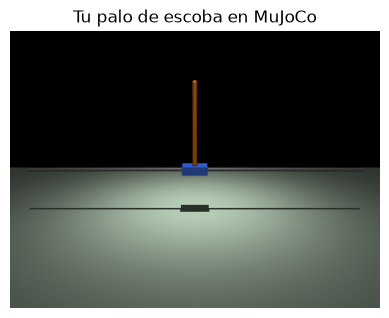

In [25]:
taller.foto(modelo, datos, seguir=False, distancia=4, titulo="Tu palo de escoba en MuJoCo");

### Paso 2 · Qué hay en `datos.qpos` (y una sorpresa con los signos)

Este robot tiene dos articulaciones, así que `datos.qpos` es una lista de **dos** números (NB09):

- `datos.qpos[0]`: dónde está el **carro**, en metros (0 = en el centro del raíl).
- `datos.qpos[1]`: el ángulo del **palo**, en **radianes** (NB03b).

Tu juguete hablaba en **grados**. Un radián son unos 57,3 grados (180 ÷ 3,14159), así que basta con
multiplicar. Guardamos ese número en una constante (apartado 4):


Ángulo del palo: 5.7 grados


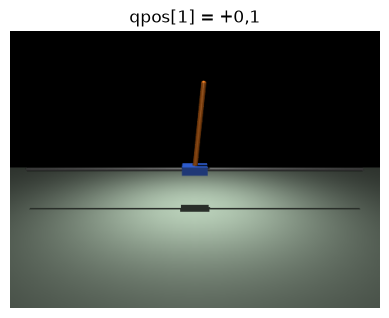

In [26]:
GRADOS = 180 / 3.14159        # para pasar de radianes a grados

datos.qpos[1] = 0.1             # inclinamos el palo 0,1 radianes, a mano (como poner_angulo del NB01)
mujoco.mj_forward(modelo, datos)
print("Ángulo del palo:", round(datos.qpos[1] * GRADOS, 1), "grados")
taller.foto(modelo, datos, seguir=False, distancia=4, titulo="qpos[1] = +0,1");

Un ángulo **positivo** inclina el palo hacia la **derecha** de la foto (hacia +x, hacia donde empuja
el motor cuando le das una orden positiva). En tu juguete era al revés: empujar con un número positivo
**aumentaba** la inclinación (`aceleración = 10 × inclinación + empuje`). Aquí, empujar el carro hacia +x
lo mete debajo de un palo que cae hacia +x, y eso **reduce** el ángulo.

No pasa nada: es solo un **convenio de signos**, como el de la pelota del NB06 (abajo positivo en tu
simulador, arriba positivo en MuJoCo). Para que tus políticas funcionen **sin tocarlas**, el traductor
del paso siguiente le dará la vuelta al signo del ángulo con un menos.


### Paso 3 · El traductor: MuJoCo habla radianes, tus políticas hablan grados

Tus políticas del proyecto reciben `(inclinacion, velocidad)` en grados y grados por segundo, y devuelven
un `empuje` entre −40 y +40. El motor de MuJoCo quiere una orden entre −1 y +1. Hacen falta dos funciones
pequeñas que traduzcan, en los dos sentidos.

**Observar** (MuJoCo → tu política): el ángulo y su velocidad de giro (`datos.qvel[1]`), en grados y con
el signo cambiado:


In [27]:
def observar():
    inclinacion = -datos.qpos[1] * GRADOS
    velocidad = -datos.qvel[1] * GRADOS
    return inclinacion, velocidad

(Fíjate en que la función **lee** las cajas `datos` y `GRADOS`, que están fuera: la idea pequeña del
apartado 11.)

Y ahora la **función de paso** de MuJoCo, hermana de tu función `paso` del apartado 5. Recibe el empuje
de tu política y hace lo mismo que la tuya, pero con física de verdad:

1. **El motor**: `empuje / EMPUJE_MAXIMO` convierte ±40 en ±1. Si la política pide más de 40, MuJoCo lo
   recorta solo a ±1 (es lo que significa `ctrlrange` en el plano): tu `if` del apartado 5, hecho por MuJoCo.
2. **El viento**: un empujoncito al azar **en la bisagra del palo** (`datos.qfrc_applied[1]` es "fuerza
   extra aplicada a la articulación 1"). Lo medimos en newton·metro; con 1,0 el viento es lo bastante fuerte
   para poner a prueba a las políticas (en el reto 1 lo quitarás).
3. **La física**: **dos** pasitos de MuJoCo de 0,01 s, para que cada decisión dure 0,02 s, como tu
   `PASO_TIEMPO`. (El humanoide hace lo mismo con 5 pasitos, NB05.)
4. **Recompensa y final**: copiados de tu `paso`, letra a letra.


In [28]:
VIENTO_MUJOCO = 1.0      # el viento, en newton·metro sobre la bisagra

def paso_mujoco(empuje):
    datos.ctrl[0] = empuje / EMPUJE_MAXIMO                                   # 1. el motor
    datos.qfrc_applied[1] = random.uniform(-VIENTO_MUJOCO, VIENTO_MUJOCO)    # 2. el viento
    mujoco.mj_step(modelo, datos)                                            # 3. la física:
    mujoco.mj_step(modelo, datos)                                            #    0,02 s

    inclinacion, velocidad = observar()
    terminado = inclinacion > CAIDA or inclinacion < -CAIDA                  # 4. igual que tu paso
    if terminado:
        recompensa = 0
    else:
        recompensa = 1 - (inclinacion / CAIDA) ** 2
    return inclinacion, velocidad, recompensa, terminado

Y **reiniciar**: `mujoco.mj_resetData` (ya escrito) pone todos los datos a cero (carro en el centro,
palo derecho, reloj a 0) y después inclinamos el palo **2 grados**, como en tu `reiniciar`. (El menos es,
otra vez, el convenio de signos: −2 grados de MuJoCo son +2 de tu juguete.)


In [29]:
def reiniciar_mujoco():
    mujoco.mj_resetData(modelo, datos)
    datos.qpos[1] = -2 / GRADOS
    return observar()

### Paso 4 · Episodios y evaluación, como en el proyecto

`episodio_mujoco` es **tu función `episodio`** del apartado 6, con dos palabras cambiadas: `reiniciar` →
`reiniciar_mujoco` y `paso` → `paso_mujoco`. Mismas semillas, mismo máximo de 500 pasos (10 segundos),
mismo `break`. Y `evaluar_mujoco`, la media de las semillas 0 a 4, igual que tu `evaluar`:


In [30]:
def episodio_mujoco(politica, semilla):
    random.seed(semilla)
    inclinacion, velocidad = reiniciar_mujoco()
    retorno = 0
    pasos_aguantados = 0
    for n in range(PASOS_MAXIMOS):
        empuje = politica(inclinacion, velocidad)                                  # EL AGENTE (tuyo)
        inclinacion, velocidad, recompensa, terminado = paso_mujoco(empuje)        # EL ENTORNO (MuJoCo)
        retorno = retorno + recompensa
        pasos_aguantados = pasos_aguantados + 1
        if terminado:
            break
    return retorno, pasos_aguantados

def evaluar_mujoco(politica):
    retornos = []
    for semilla in range(5):
        retorno, pasos_aguantados = episodio_mujoco(politica, semilla)
        retornos.append(retorno)
    return sum(retornos) / len(retornos)

### Paso 5 · Tus cuatro políticas, contra la física de verdad

Las mismas funciones del proyecto (`politica_nada`, `politica_azar`, `politica_solo_inclinacion`,
`politica_a_mano`), **sin cambiarles nada**. Un bucle sobre una lista de políticas (sí: una lista puede
guardar funciones, igual que números) y una lista de nombres en paralelo (NB09):


In [31]:
politicas = [politica_nada, politica_azar, politica_solo_inclinacion, politica_a_mano]
nombres = ["Nada", "Al azar", "Solo inclinación", "Inclinación + velocidad"]

for i in range(len(politicas)):
    print(nombres[i], "->", round(evaluar_mujoco(politicas[i]), 1), "| juguete:", round(evaluar(politicas[i]), 1))

Nada -> 32.4 | juguete: 44.8
Al azar -> 22.9 | juguete: 43.2
Solo inclinación -> 173.0 | juguete: 296.0
Inclinación + velocidad -> 331.8 | juguete: 499.9


| Política | Tu juguete | MuJoCo |
|---|---|---|
| Nada | 44,8 | 32,4 |
| Al azar | 43,2 | 22,9 |
| Solo inclinación | 296,0 | 173,0 |
| Inclinación + velocidad | **499,9** | **331,8** |

El **orden** es el mismo: nada y azar fracasan (el azar, otra vez, **peor** que no hacer nada), y mirar la
velocidad mejora mucho a mirar solo la inclinación. Tu juguete acertó en lo importante. Pero... la campeona
del proyecto ya no llega a 500. ¿Qué le pasa? Hagamos lo que hacen los profesionales (apartado 9): mirar
episodio a episodio. Esta vez, además, preguntamos **dónde acaba el carro** (`datos.qpos[0]`):


In [32]:
for semilla in range(5):
    retorno, pasos_aguantados = episodio_mujoco(politica_a_mano, semilla)
    print("semilla", semilla, "| retorno", round(retorno, 1), "| aguantó", pasos_aguantados,
          "pasos | carro en x =", round(datos.qpos[0], 2), "m")

semilla 0 | retorno 134.6 | aguantó 140 pasos | carro en x = 1.8 m
semilla 1 | retorno 280.1 | aguantó 287 pasos | carro en x = -1.8 m
semilla 2 | retorno 499.9 | aguantó 500 pasos | carro en x = 1.69 m
semilla 3 | retorno 244.5 | aguantó 251 pasos | carro en x = 1.8 m
semilla 4 | retorno 499.8 | aguantó 500 pasos | carro en x = 0.69 m


¡Ahí está! En los episodios que fallan, el carro termina en **x = 1,8** o **−1,8**: **el final del raíl**.

Esto es lo que tu juguete **no tenía**. En tu física, solo existía el palo: el "carrito" podía moverse
para siempre sin llegar a ningún sitio. En MuJoCo hay un carro **de verdad**, que se mueve de verdad, y el
raíl **se acaba** (el `range="-1.8 1.8"` del plano). La política "inclinación + velocidad" mantiene el palo
de pie, sí, pero para hacerlo mueve el carro, y el carro se va quedando con **velocidad** hacia un lado
(al enderezar el palo del principio y al responder a cada golpe de viento). Nada en la política lo frena,
porque ella **no mira el carro**... hasta que el carro **choca con el tope**, se para en seco y el palo, sin
nadie debajo, se cae.

Míralo (el vídeo, ya escrito, repite exactamente el episodio de la semilla 0: el carro decide cada dos
pasitos, con el mismo viento; la línea `% 2 == 0` significa "solo en los pasitos pares"):


In [33]:
def control_video(modelo, datos):
    if round(datos.time / 0.01) % 2 == 0:                  # cada 0,02 s, como en paso_mujoco
        inclinacion, velocidad = observar()
        datos.ctrl[0] = politica_del_video(inclinacion, velocidad) / EMPUJE_MAXIMO
        datos.qfrc_applied[1] = random.uniform(-VIENTO_MUJOCO, VIENTO_MUJOCO)

politica_del_video = politica_a_mano
random.seed(0)
reiniciar_mujoco()
taller.video(modelo, datos, segundos=3.3, control=control_video, nombre="nb11_rail",
             seguir=False, distancia=5);

### Paso 6 · ¿Lo arregla la búsqueda aleatoria?

Quizá el 30 y el 8 no son buenas ruedecillas para MuJoCo. Probemos **tu búsqueda aleatoria** del apartado
12 sobre la física de verdad: los mismos 20 candidatos (`candidatos_inclinacion` y `candidatos_velocidad`
siguen en la memoria del cuaderno), la misma `politica_ruedecillas`, solo que evaluada con `evaluar_mujoco`:


In [34]:
mejor_retorno = -1
for intento in range(20):
    ruedecilla_inclinacion = candidatos_inclinacion[intento]
    ruedecilla_velocidad = candidatos_velocidad[intento]
    puntos = evaluar_mujoco(politica_ruedecillas)
    if puntos > mejor_retorno:
        mejor_retorno = puntos
        mejor_inclinacion = ruedecilla_inclinacion
        mejor_velocidad = ruedecilla_velocidad

print("Mejores ruedecillas en MuJoCo:", round(mejor_inclinacion, 1), "y", round(mejor_velocidad, 1),
      "| retorno", round(mejor_retorno, 1))

Mejores ruedecillas en MuJoCo: 47.9 y 6.7 | retorno 336.0


**336 puntos**, como mucho. Ninguna pareja de ruedecillas lo salva. Y es lógico: el problema no es
**cuánto** empujar, sino que la política **no sabe dónde está el carro**. Con la información que tiene
(inclinación y velocidad del palo), no puede saber que se acerca al final del raíl.

¿Te suena? Es **la misma lección del apartado 10**, un nivel más arriba: allí a la política le faltaba la
velocidad (el problema de la foto); aquí le falta **la posición del carro**. En un mundo más real, hay
más cosas que mirar.


### Paso 7 · Política 5: mirar también el carro

Una política que mira **cuatro** números: la inclinación y la velocidad del palo (como antes) y además la
**posición** del carro (`datos.qpos[0]`) y su **velocidad** (`datos.qvel[0]`), que lee directamente de la
caja `datos` de fuera. Cuatro ruedecillas. Los valores de abajo son los de un ingeniero de control (los
encontrarás también en el plan del curso para este robot; aprenderás a calcularlos tú mismo en el NB40):


In [35]:
ruedecilla_inclinacion = 2.1
ruedecilla_velocidad = 0.56
ruedecilla_carro = 4
ruedecilla_vel_carro = 8

def politica_con_carro(inclinacion, velocidad):
    return (-ruedecilla_inclinacion * inclinacion - ruedecilla_velocidad * velocidad
            + ruedecilla_carro * datos.qpos[0] + ruedecilla_vel_carro * datos.qvel[0])

for semilla in range(5):
    retorno, pasos_aguantados = episodio_mujoco(politica_con_carro, semilla)
    print("semilla", semilla, "| retorno", round(retorno, 1), "| aguantó", pasos_aguantados,
          "pasos | carro en x =", round(datos.qpos[0], 2), "m")
print("Media:", round(evaluar_mujoco(politica_con_carro), 1))

semilla 0 | retorno 490.1 | aguantó 500 pasos | carro en x = 0.54 m
semilla 1 | retorno 493.6 | aguantó 500 pasos | carro en x = 0.46 m
semilla 2 | retorno 484.1 | aguantó 500 pasos | carro en x = 0.45 m
semilla 3 | retorno 493.1 | aguantó 500 pasos | carro en x = 0.37 m
semilla 4 | retorno 491.7 | aguantó 500 pasos | carro en x = 1.36 m
Media: 490.5


**Los cinco episodios completos**, con el carro bien lejos de los topes, y unos **490 puntos de media**.

Fíjate en dos cosas muy curiosas de esas ruedecillas:

- Las del palo son **pequeñas** (2,1 y 0,56, frente a 30 y 8): empujar con suavidad basta para tener el
  palo de pie, y empujar fuerte lanza el carro de un lado a otro, hacia los topes.
- Las del carro van con signo **más**: si el carro se ha ido a la derecha, la política lo empuja... ¡**más
  a la derecha**! Parece al revés, pero es lo que haces tú con una escoba en la mano cuando quieres volver
  a tu sitio: primero das un empujoncito "hacia fuera", eso **inclina el palo hacia dentro**, y entonces la
  parte de la inclinación hace que el carro lo siga de vuelta hacia el centro. Para ir a la izquierda, el
  palo tiene que inclinarse primero a la izquierda.

Y la prueba de verdad (apartado 12): **mundos nuevos**, las semillas 100 a 109.


In [36]:
completos = 0
for semilla in range(100, 110):
    retorno, pasos_aguantados = episodio_mujoco(politica_con_carro, semilla)
    if pasos_aguantados == PASOS_MAXIMOS:
        completos = completos + 1
print("Episodios completos en 10 mundos nuevos:", completos, "de 10")

Episodios completos en 10 mundos nuevos: 10 de 10


**10 de 10.** Míralo aguantar (5 segundos de la semilla 0):

In [37]:
politica_del_video = politica_con_carro
random.seed(0)
reiniciar_mujoco()
taller.video(modelo, datos, segundos=5, control=control_video, nombre="nb11_con_carro",
             seguir=False, distancia=5);

### Paso 8 · Que el ordenador encuentre solo las cuatro ruedecillas

El gran final, otra vez: ¿puede tu **búsqueda aleatoria** encontrar sola unas buenas ruedecillas, ahora que
son cuatro? Con cuatro ruedecillas hay muchas más combinaciones, así que le damos **50** candidatos. Primero
los inventamos todos (como en el apartado 12):


In [38]:
random.seed(42)
candidatos = []
for intento in range(50):
    candidatos.append([random.uniform(0, 50), random.uniform(0, 20), random.uniform(0, 20), random.uniform(0, 20)])

print("Primer candidato:", candidatos[0])

Primer candidato: [31.971339922894188, 0.5002151044533387, 5.500586367382385, 4.4642147629764555]


(Cada candidato es una **lista de cuatro números**, y `candidatos` es una lista de esas listas: una
"lista de listas", que verás con calma en el NB11b. `candidatos[intento][0]` es la primera ruedecilla del
candidato número `intento`.)

Y el bucle del aprendizaje, el mismo de siempre:


In [39]:
mejor_retorno = -1
for intento in range(50):
    ruedecilla_inclinacion = candidatos[intento][0]
    ruedecilla_velocidad = candidatos[intento][1]
    ruedecilla_carro = candidatos[intento][2]
    ruedecilla_vel_carro = candidatos[intento][3]
    puntos = evaluar_mujoco(politica_con_carro)
    if puntos > mejor_retorno:
        mejor_retorno = puntos
        mejor = candidatos[intento]
        print("intento", intento, "| ruedecillas", round(mejor[0], 1), round(mejor[1], 1),
              round(mejor[2], 1), round(mejor[3], 1), "| retorno", round(puntos, 1), "  <- ¡nuevo mejor!")

intento 0 | ruedecillas 32.0 0.5 5.5 4.5 | retorno 349.0   <- ¡nuevo mejor!
intento 1 | ruedecillas 36.8 13.5 17.8 1.7 | retorno 375.1   <- ¡nuevo mejor!


intento 7 | ruedecillas 42.4 12.1 16.1 14.6 | retorno 415.2   <- ¡nuevo mejor!


intento 17 | ruedecillas 15.8 5.4 4.2 18.9 | retorno 423.1   <- ¡nuevo mejor!
intento 22 | ruedecillas 4.5 0.9 2.2 12.5 | retorno 491.5   <- ¡nuevo mejor!


El ordenador encuentra **solo** unas ruedecillas de unos **491 puntos**, tan buenas como las del
ingeniero en los 5 mundos de práctica. Y fíjate en cuáles son: **4,5 / 0,9 / 2,2 / 12,5**. ¡Se parecen
muchísimo a las del ingeniero (2,1 / 0,56 / 4 / 8)! Pequeñas para el palo y **positivas para el carro**: la
búsqueda ha "redescubierto" el truco de empujar hacia fuera para volver, sin que nadie se lo explicara.

¿Y en mundos nuevos?


In [40]:
ruedecilla_inclinacion = mejor[0]
ruedecilla_velocidad = mejor[1]
ruedecilla_carro = mejor[2]
ruedecilla_vel_carro = mejor[3]

completos = 0
for semilla in range(100, 110):
    retorno, pasos_aguantados = episodio_mujoco(politica_con_carro, semilla)
    if pasos_aguantados == PASOS_MAXIMOS:
        completos = completos + 1
print("Lo aprendido, en 10 mundos nuevos:", completos, "de 10 completos")

Lo aprendido, en 10 mundos nuevos: 8 de 10 completos


**8 de 10.** Aquí la física de verdad nos da otra lección que el juguete no nos dio: la búsqueda eligió
sus ruedecillas mirando **solo cinco vientos**, y en dos de los diez mundos nuevos el carro vuelve a
acabar contra el tope. En el juguete, 5 mundos bastaban para generalizar; en un mundo más difícil, **5
mundos de práctica se quedan cortos** (reto 3). Por eso los profesionales entrenan con muchísimos
episodios distintos, y por eso las ruedecillas del ingeniero, que salen de entender la física, aguantan
los 10.

Recapitulemos:

| | Tu juguete | MuJoCo |
|---|---|---|
| Nada / azar | 44,8 / 43,2 | 32,4 / 22,9 |
| Solo inclinación | 296,0 | 173,0 |
| Inclinación + velocidad (30 y 8) | **499,9** | 331,8 (choca con el final del raíl) |
| Mejor búsqueda con 2 ruedecillas | 499,9 | 336,0 |
| **Mirando también el carro (4 ruedecillas)** | (no existe el carro) | **490,5** (5/5; 10/10 en mundos nuevos) |
| Búsqueda aleatoria con 4 ruedecillas | — | **491,5** (8/10 en mundos nuevos) |


### Tus retos

**Reto 1.** Pon el viento a cero (`VIENTO_MUJOCO = 0`) y repite el episodio de la semilla 0 con
`politica_solo_inclinacion` y con `politica_a_mano`, mirando dónde acaba el carro. Predice antes: sin viento,
¿se libra `politica_a_mano` del final del raíl? (Cuando acabes, vuelve a ponerlo a 1.0.)

**Reto 2.** Haz el palo **el doble de largo**: en `PALO`, cambia `fromto="0 0 0 0 0 1"` por
`fromto="0 0 0 0 0 2"`, vuelve a ejecutar la celda del plano y evalúa `politica_con_carro` con las
ruedecillas del ingeniero (2,1 / 0,56 / 4 / 8). Antes, predice: ¿es más fácil o más difícil equilibrar un
palo largo? (Piensa en una escoba frente a un lápiz.)

**Reto 3.** Repite la búsqueda del Paso 8, pero evaluando con **diez** semillas en vez de cinco. Escribe una
`evaluar_mujoco_10` igual que `evaluar_mujoco` pero con `range(10)`, y úsala dentro del bucle. ¿Aguanta
mejor lo aprendido en los mundos 100-109?

**Reto 4 (piensa).** En el juguete, el empuje máximo era una regla (`EMPUJE_MAXIMO = 40`). ¿Dónde está esa
regla en MuJoCo, y qué número tendrías que cambiar para tener un motor más débil?

<details>
<summary>▶ Solución Reto 1</summary>

Sorpresa doble:

- `politica_a_mano` **no** se libra: sin una gota de viento, choca con el tope (x = −1,8) en el paso
  **280**. Al enderezar los 2 grados del principio, el carro arranca con algo de velocidad... y como la
  política no mira el carro, nunca lo frena. El viento solo hacía que pasara antes.
- `politica_solo_inclinacion` aguanta los **500 pasos** (retorno unos **436**, con el carro en x = −0,49):
  el palo oscila un poco, pero en MuJoCo, sin viento, no llega a caerse ni a chocar.

Moraleja: el problema del raíl no lo crea el viento; lo crea **no mirar el carro**. (Para la política con
carro, sin viento, el carro acaba en el centro exacto y el retorno es 499,9.)
</details>

<details>
<summary>▶ Solución Reto 2</summary>

**Más fácil**: un palo largo cae **más despacio** (como una escoba frente a un lápiz: el NB37 te dirá por
qué con números). Con el palo de 2 metros, las ruedecillas del ingeniero siguen completando los 5
episodios, con un retorno de unos **495,5** (más alto que los 490,5 del palo de 1 m: el palo se tuerce menos).
Al terminar, vuelve a poner `fromto="0 0 0 0 0 1"` y ejecuta de nuevo la celda del plano.
</details>

<details>
<summary>▶ Solución Reto 3</summary>

```python
def evaluar_mujoco_10(politica):
    retornos = []
    for semilla in range(10):
        retorno, pasos_aguantados = episodio_mujoco(politica, semilla)
        retornos.append(retorno)
    return sum(retornos) / len(retornos)
```

y en el bucle del Paso 8, `puntos = evaluar_mujoco_10(politica_con_carro)`. Ahora la búsqueda no se deja
engañar por cinco vientos "fáciles": elige otro candidato (10,7 / 2,6 / 18,7 / 11,4, retorno medio 471,7 en sus
diez mundos de práctica) que completa **9 de 10** mundos nuevos, en vez de 8. Más
variedad de práctica → mejor generalización. Tarda el doble, claro: es el precio.
</details>

<details>
<summary>▶ Solución Reto 4</summary>

En el plano: `<motor ... gear="10" ctrlrange="-1 1"/>`. La orden se recorta a ±1 (`ctrlrange`) y se
multiplica por `gear`, así que la fuerza máxima son **10 newtons**. Para un motor más débil, cambia `gear`
(por ejemplo, `gear="3"`: con solo 3 newtons, ni la política con carro aguanta; el retorno cae a unos 58).
En tu juguete era una constante de Python; en MuJoCo es un número del plano del
robot: el **cuerpo** (NB01), no la mente.
</details>

### Qué has aprendido de MuJoCo hoy

- A **escribir el plano MJCF de un robot propio**: `option`, `worldbody`, `body` dentro de `body` (el
  árbol), articulaciones `slide` (con `range`) y `hinge`, formas `geom` con `mass`, y un `motor` con `gear`
  y `ctrlrange`.
- `qpos`/`qvel` del palo: `[posición del carro, ángulo del palo]`, en metros y **radianes**; cuidado con el
  **convenio de signos**.
- A conectar **tus** políticas a MuJoCo con un **traductor** (`observar`, `paso_mujoco`, `reiniciar_mujoco`
  con `mj_resetData`), a meter **viento** con `qfrc_applied` y a decidir cada 2 pasitos.
- Que la física de verdad tiene cosas que tu juguete no tenía (**el carro y el final del raíl**), y que para
  ellas hace falta **más información** en la observación (4 ruedecillas en vez de 2).
- Que tu **búsqueda aleatoria funciona sobre MuJoCo** (491,5 puntos, ruedecillas parecidas a las de un
  ingeniero), pero que generalizar a mundos nuevos exige practicar en **más** mundos.

Este palo de escoba (el fichero `robots/palo_escoba.xml`) será tu banco de pruebas durante mucho tiempo: en
él probarás la imitación, las redes neuronales y, en el NB29, tu **primer entrenamiento de verdad** en
MuJoCo. En la práctica del NB11b leerás, línea a línea, un **script de MuJoCo de verdad** que lo controla, y
reconocerás en él todas las formas nuevas de Python de esa lección.


## 17 · Posdata: se acaba la Parte 1

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con este proyecto **termina la Parte 1**. Mira hacia atrás: hace siete lecciones no sabías qué era `print`. Hoy has
construido un entorno de aprendizaje por refuerzo, has diagnosticado una política que fallaba mirando sus datos, y has
hecho que un ordenador **aprenda solo** a mantener un palo de pie. Con tu propio código, línea a línea. Y
has escrito el plano de tu primer robot de MuJoCo y has descubierto que la física de verdad pide mirar más cosas.

Antes de la Parte 2, el **NB11b** te presentará unas cuantas formas de escribir Python que vas a encontrar enseguida (argumentos con nombre, tuplas, listas de listas...). Y en la **Parte 2** vamos a por las dos cosas que nos faltan para el humanoide: las **matemáticas** que permiten girar
miles de ruedecillas a la vez con inteligencia (empezando, desde cero, por las **flechas** —los vectores— y las
**pendientes**), y las herramientas de Python para manejar montones de números a toda velocidad. Todo, como siempre,
desde el principio y en gotas.
